## Logistical Regression Model

### Import Tools 

In [144]:
import pandas as pd #pandas -> data cleaning, feature engineering 
from sklearn.linear_model import LogisticRegression #for our model
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix #for evaluation on the model 
from sklearn.model_selection import train_test_split #to group the data eg. training, testing
from matplotlib import pyplot as plt # for visualization

In [145]:
df = pd.read_csv('Titanic-Dataset.csv') #we import the data locally and name it df

### Split the Data

In [146]:
X = df[['Pclass', 'Sex', 'Age', 'Fare']].copy()#the columns we'll be using for our first training set
X['Sex'] = X['Sex'].map({'male':0, 'female':1})#encode the sex column
y = df['Survived'] #what we hope to perdict 

In [5]:
X.isna().sum() #checking for missing values 

Pclass      0
Sex         0
Age       177
Fare        0
dtype: int64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, #varibles to target 
    test_size=0.2, #the batching
    random_state=42, #randomly produce the same split every time 
    stratify= y #keeps approximately the same survival/non-survival proportions in both sets  
)

In [7]:
median = X_train['Age'].median()#find the median set for both training and testing set
median2 = X_test['Age'].median()

In [8]:
X_train['Age'] = X_train['Age'].fillna(median)# fill in for missing aga values 
X_test['Age'] = X_test['Age'].fillna(median)

In [9]:
print(X_train.isna().sum())# check
print(X_test.isna().sum())

Pclass    0
Sex       0
Age       0
Fare      0
dtype: int64
Pclass    0
Sex       0
Age       0
Fare      0
dtype: int64


### Create a Baseline
This let's us tell if our survived and not survived are of equal sample numbers in the dataset or which one is more 

In [10]:
baselineClass = y_train.mode()[0]#this tells us that 'did not survive' is more common in our data

baselineAccuracy = (y_test == baselineClass).mean() * 100

baselineClass, baselineAccuracy

(np.int64(0), np.float64(61.452513966480446))

In [135]:
model = LogisticRegression(max_iter=1000)

In [136]:
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [137]:
modelAccuracy = model.score(X_test, y_test) * 100

In [138]:
[[ baselineAccuracy, modelAccuracy ]]

[[np.float64(61.452513966480446), 78.77094972067039]]

In [139]:
yPred = model.predict(X_test)

In [140]:
yPred[:10]

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0])

In [141]:
[[ yPred[:10], y_test[:10]]]

[[array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0]),
  565    0
  160    0
  553    1
  860    0
  241    1
  559    1
  387    1
  536    0
  698    0
  99     0
  Name: Survived, dtype: int64]]

In [142]:
print(classification_report(y_test, yPred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       110
           1       0.75      0.68      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



In [18]:
confusionMatrix = confusion_matrix(y_test, yPred)
confusionMatrix

array([[94, 16],
       [22, 47]])

# Precision and Recall

In [19]:
 print(classification_report(y_test,yPred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       110
           1       0.75      0.68      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



In [20]:
yProb = model.predict_proba(X_test)[:, 1]
yProb[:10]

array([0.10596377, 0.0561998 , 0.11033039, 0.06168765, 0.55295579,
       0.49025717, 0.7450901 , 0.35293448, 0.34759057, 0.20560858])

In [21]:
yPred3 = (yProb >= 0.3).astype(int)
print(classification_report(y_test, yPred3))

              precision    recall  f1-score   support

           0       0.86      0.73      0.79       110
           1       0.65      0.81      0.72        69

    accuracy                           0.76       179
   macro avg       0.76      0.77      0.76       179
weighted avg       0.78      0.76      0.76       179



In [22]:
yPred7 = (yProb >= 0.7).astype(int)
print(classification_report(y_test, yPred7))

              precision    recall  f1-score   support

           0       0.74      0.96      0.83       110
           1       0.89      0.45      0.60        69

    accuracy                           0.77       179
   macro avg       0.81      0.71      0.72       179
weighted avg       0.79      0.77      0.74       179



In [23]:
X_train.shape

(712, 4)

In [24]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  712 non-null    int64  
 1   Sex     712 non-null    int64  
 2   Age     712 non-null    float64
 3   Fare    712 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 27.8 KB


In [25]:
X_train.isna().sum()

Pclass    0
Sex       0
Age       0
Fare      0
dtype: int64

In [26]:
dfff = df.loc[X_train.index].copy()

In [27]:
dfff['familySize'] = dfff['SibSp'] + dfff['Parch'] + 1

In [28]:
summary = (dfff.groupby('familySize').agg(PassengerCount=('PassengerId', 'size'),
                               survivalPer=('Survived', 'mean')).assign(survivalPer= lambda x: x['survivalPer'] * 100)
    .sort_values('familySize'))

In [29]:
dfff

,Name,Sex,Age,SibSp,Parch,Embarked,Ticket,Fare,Cabin,PassengerId,Pclass,Survived,familySize
692,"Lam, Mr. Ali",male,NaN,0,0,S,1601,56.4958,NaN,693,3,1,1
481,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,S,239854,0.0000,NaN,482,2,0,1
527,"Farthing, Mr. John",male,NaN,0,0,S,PC 17483,221.7792,C95,528,1,0,1
855,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,S,392091,9.3500,NaN,856,3,1,2
801,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,S,C.A. 31921,26.2500,NaN,802,2,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,"Mockler, Miss. Helen Mary ""Ellie""",female,NaN,0,0,Q,330980,7.8792,NaN,360,3,1,1
258,"Ward, Miss. Anna",female,35.0,0,0,C,PC 17755,512.3292,NaN,259,1,1,1
736,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0,1,3,S,W./C. 6608,34.3750,NaN,737,3,0,5
462,"Gee, Mr. Arthur H",male,47.0,0,0,S,111320,38.5000,E63,463,1,0,1


In [30]:
summary

,PassengerCount,survivalPer
familySize,,
1,434,29.953917
2,129,55.038760
3,77,62.337662
4,22,72.727273
5,14,21.428571
6,16,6.250000
7,11,36.363636
8,4,0.000000
11,5,0.000000


In [31]:
dfff['IsAlone'] = dfff['familySize'] == 1

In [32]:
dfff['IsAlone'] = dfff['IsAlone'].map({True:1, False:0})

In [33]:
dfff[['familySize', 'IsAlone']].head(5)

,familySize,IsAlone
692,1,1
481,1,1
527,1,1
855,2,0
801,3,0


In [34]:
X_trainNew = X_train.copy()
X_trainNew['IsAlone'] = dfff['IsAlone']

In [35]:
X_trainNew.head(5)

,Pclass,Sex,Age,Fare,IsAlone
692,3,0,28.5,56.4958,1
481,2,0,28.5,0.0000,1
527,1,0,28.5,221.7792,1
855,3,1,18.0,9.3500,0
801,2,1,31.0,26.2500,0


In [83]:
X_trainNew.shape

(712, 5)

In [36]:
X_trainNew['familySize'] = dfff['familySize']

In [41]:
X_trainNew.head(5), X_trainNew.shape

(     Pclass  Sex   Age      Fare  IsAlone  familySize
 692       3    0  28.5   56.4958        1           1
 481       2    0  28.5    0.0000        1           1
 527       1    0  28.5  221.7792        1           1
 855       3    1  18.0    9.3500        0           2
 801       2    1  31.0   26.2500        0           3,
 (712, 6))

In [42]:
X_forValidation = X_trainNew.copy()

In [45]:
X_forValidation['Age'] = df['Age']

In [47]:
X_forValidation.isna().sum()

Pclass          0
Sex             0
Age           137
Fare            0
IsAlone         0
familySize      0
dtype: int64

In [63]:
X_fit, X_val,y_fit, y_val = train_test_split(
    X_forValidation, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [64]:
X_fit.shape, X_val.shape, y_fit.shape, y_val.shape

((569, 6), (143, 6), (569,), (143,))

In [65]:
X_forValidation.index.equals(y_train.index)

True

In [66]:
median = X_fit['Age'].median()

In [68]:
X_fit['Age'] = X_fit['Age'].fillna(median)

In [69]:
X_val['Age'] = X_val['Age'].fillna(median)

In [72]:
X_fit['Age'].isna().sum(), X_val['Age'].isna().sum()

(np.int64(0), np.int64(0))

In [77]:
originalFeatures = ['Pclass', 'Sex', 'Age', 'Fare']

In [78]:
X_fit[originalFeatures]

,Pclass,Sex,Age,Fare
242,2,0,29.0,10.5000
450,2,0,36.0,27.7500
721,3,0,17.0,7.0542
733,2,0,23.0,13.0000
191,2,0,19.0,13.0000
...,...,...,...,...
451,3,0,29.0,19.9667
289,3,1,22.0,7.7500
819,3,0,10.0,27.9000
812,2,0,35.0,10.5000


In [80]:
modelOriginal = LogisticRegression(max_iter=1000)

In [82]:
modelOriginal.fit(X_fit[originalFeatures], y_fit)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [85]:
yValPredOriginal = modelOriginal.predict(X_val[originalFeatures])

In [86]:
print(classification_report(y_val, yValPredOriginal))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80        88
           1       0.69      0.67      0.68        55

    accuracy                           0.76       143
   macro avg       0.74      0.74      0.74       143
weighted avg       0.75      0.76      0.75       143



In [87]:
model2 = LogisticRegression(max_iter=1000)

In [88]:
model2.fit(X_fit, y_fit)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [90]:
yValPred2 = model2.predict(X_val)

In [91]:
print(classification_report(y_val, yValPred2))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82        88
           1       0.72      0.65      0.69        55

    accuracy                           0.77       143
   macro avg       0.76      0.75      0.75       143
weighted avg       0.77      0.77      0.77       143



In [92]:
IsAloneCol = ['Pclass', 'Sex', 'Age', 'Fare', 'IsAlone']

In [114]:
modelIsAlone = LogisticRegression(max_iter=1000)

In [115]:
modelIsAlone.fit(X_fit[IsAloneCol], y_fit)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [116]:
yPredA = modelIsAlone.predict(X_val[IsAloneCol])

In [117]:
print(classification_report(y_val, yPredA))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80        88
           1       0.69      0.67      0.68        55

    accuracy                           0.76       143
   macro avg       0.74      0.74      0.74       143
weighted avg       0.75      0.76      0.75       143



In [100]:
family = ['Pclass', 'Sex', 'Age', 'Fare', 'familySize']

In [118]:
modelf = LogisticRegression(max_iter=1000)

In [119]:
modelf.fit(X_fit[family], y_fit)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [120]:
ypredf = modelf.predict(X_val[family])

In [133]:
print(classification_report(y_val, ypredf))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81        88
           1       0.71      0.65      0.68        55

    accuracy                           0.76       143
   macro avg       0.75      0.74      0.75       143
weighted avg       0.76      0.76      0.76       143



In [149]:
modelComparison = pd.DataFrame({'model': ['Main', 'IsAlone','familySize',
                                          'Main + all'],
                                'precision': [0.69, 0.69, 0.71, 0.72],
                               'recall': [0.67, 0.67, 0.65,0.65],
                               'f1-score': [0.68, 0.68, 0.68, 0.69]})

In [150]:
modelComparison

,model,precision,recall,f1-score
0,Main,0.69,0.67,0.68
1,IsAlone,0.69,0.67,0.68
2,familySize,0.71,0.65,0.68
3,Main + all,0.72,0.65,0.69


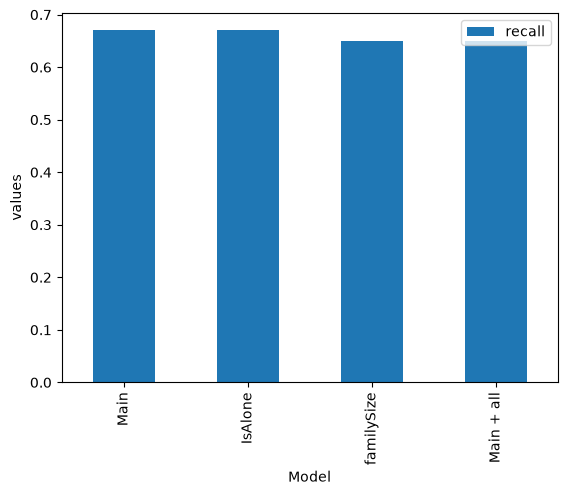

In [169]:
modelComparison.plot(kind='bar', x='model', y='recall')
plt.xlabel('Model')
plt.ylabel('values')
plt.show()

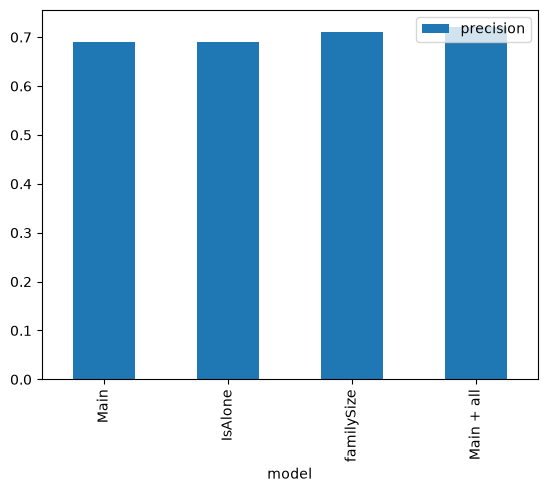

In [170]:
modelComparison.plot(kind='bar', x='model', y='precision')
plt.show()

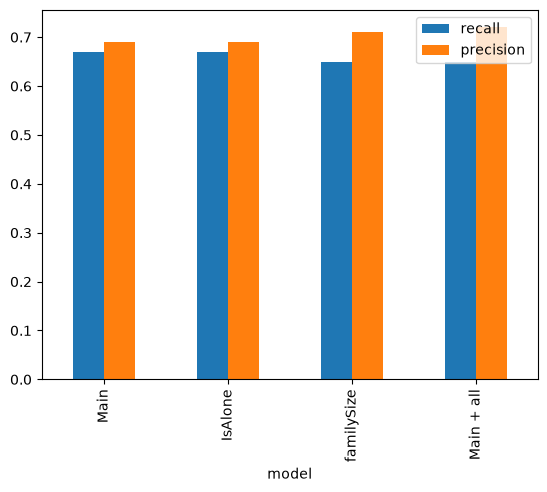

In [171]:
modelComparison.plot(kind='bar', x='model', y=['recall', 'precision'])
plt.show()

Adding IsAlone alone left precision and recall unchanged compared with the original model. Adding both IsAlone and familySize increased precision from 0.69 to 0.72, but reduced recall from 0.67 to 0.65, meaning its survivor predictions were more often correct, but it missed slightly more actual survivors on this validation set.